# Healthcare Encounters — Exploratory Data Analysis

## Objective

This notebook explores a synthetic healthcare encounters dataset to assess data quality, describe patient and encounter characteristics, and investigate patterns in utilization, cost, and readmission.

## Analysis workflow

1. Data loading and initial inspection  
2. Data quality assessment  
3. Descriptive and categorical analysis  
4. Time-based and cross-sectional analysis  
5. Patient-level and cost-focused analysis  
6. Visual exploratory analysis  
7. Key findings


In [2]:
import pandas as pd
import numpy as np
import datetime

## 1. Data Loading

Load the dataset and confirm that it is available for analysis.


In [4]:
# Read csv into pandas DataFrame

root_path = "../data"
file_name = "healthcare_encounters_eda"

df = pd.read_csv(f"{root_path}/{file_name}.csv")

In [5]:
# Get number of rows and cols using df.shape

rows, cols = df.shape

print(f"There are {rows} rows and {cols} columns in the dataset")

There are 75000 rows and 15 columns in the dataset


## 2. Dataset Overview

Inspect the dataset dimensions and review representative records to understand its structure and level of granularity.


In [7]:
# Display 5 first rows of the dataset
df.head()

,encounter_id,patient_id,admission_date,discharge_date,age,gender,region,facility_type,diagnosis_category,admission_type,length_of_stay_days,total_cost_eur,insurance_type,readmitted_30d,patient_satisfaction_score
0,ENC-0024295,108983,2025-11-30,2025-12-02,46.0,Male,Basque Country,University Hospital,Respiratory,Urgent,2,3948.04,Private,No,7.9
1,ENC-0028410,125400,2024-11-20,2024-11-22,54.0,Male,Madrid,Specialist Clinic,Cardiovascular,Observation,2,4195.62,Public,No,7.1
2,ENC-0071214,107225,2024-06-16,2024-06-21,61.0,Female,Madrid,Community Hospital,Cardiovascular,Emergency,5,13152.90,Public,Yes,8.3
3,ENC-0051899,103487,2024-02-20,2024-02-22,61.0,Male,Madrid,Community Hospital,Musculoskeletal,Elective,2,5697.77,Public,No,9.0
4,ENC-0025778,127610,2024-12-03,2024-12-09,41.0,Male,Catalonia,Specialist Clinic,Cardiovascular,Urgent,6,5547.88,Private,No,7.7


In [8]:
# Display 5 last rows of the dataset
df.tail()

,encounter_id,patient_id,admission_date,discharge_date,age,gender,region,facility_type,diagnosis_category,admission_type,length_of_stay_days,total_cost_eur,insurance_type,readmitted_30d,patient_satisfaction_score
74995,ENC-0033292,122016,2025-03-15,2025-03-23,67.0,Male,Catalonia,University Hospital,Respiratory,Elective,8,6143.99,Public,No,8.7
74996,ENC-0039746,102769,2025-03-14,2025-03-22,96.0,Female,Madrid,Community Hospital,Endocrine,Urgent,8,5232.81,Public,Yes,9.4
74997,ENC-0004331,112226,2025-03-16,2025-03-16,61.0,Female,Madrid,General Hospital,Endocrine,Elective,0,2787.54,Public,No,6.8
74998,ENC-0073240,122344,2024-06-14,2024-06-18,72.0,Female,Andalusia,University Hospital,Endocrine,Urgent,4,5400.68,Public,No,8.3
74999,ENC-0009576,119522,2024-12-09,2024-12-14,NaN,Male,Galicia,University Hospital,Musculoskeletal,Observation,5,98044.87,Public,No,4.6


In [9]:
# Display 5 random rows of the dataset
df.sample(n=5)

,encounter_id,patient_id,admission_date,discharge_date,age,gender,region,facility_type,diagnosis_category,admission_type,length_of_stay_days,total_cost_eur,insurance_type,readmitted_30d,patient_satisfaction_score
38963,ENC-0048290,108742,2024-09-26,2024-09-29,51.0,Female,Catalonia,General Hospital,Endocrine,Elective,3,3985.91,Private,No,8.1
1140,ENC-0020043,104203,2025-09-26,2025-10-01,45.0,Female,Catalonia,General Hospital,Mental Health,Observation,5,4267.02,Public,No,NaN
67214,ENC-0071919,120412,2025-11-23,2025-11-26,62.0,Male,Valencia,University Hospital,Injury,Emergency,3,6264.95,Private,No,9.8
5728,ENC-0064583,131137,2024-12-17,2024-12-18,33.0,Female,Valencia,Community Hospital,Gastrointestinal,Emergency,1,3478.85,Public,No,8.8
51338,ENC-0060163,131121,2025-10-11,2025-10-19,34.0,Female,Catalonia,University Hospital,Cardiovascular,Emergency,8,16400.86,Public,No,6.3


## 3. Data Quality Assessment

Review column types, missing values, and duplicate records before proceeding with the analysis.


In [11]:
# Display column names, their data types and count of non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   encounter_id                75000 non-null  object 
 1   patient_id                  75000 non-null  int64  
 2   admission_date              75000 non-null  object 
 3   discharge_date              74609 non-null  object 
 4   age                         74237 non-null  float64
 5   gender                      74569 non-null  object 
 6   region                      74485 non-null  object 
 7   facility_type               75000 non-null  object 
 8   diagnosis_category          74373 non-null  object 
 9   admission_type              75000 non-null  object 
 10  length_of_stay_days         75000 non-null  int64  
 11  total_cost_eur              75000 non-null  float64
 12  insurance_type              74458 non-null  object 
 13  readmitted_30d              750

In [12]:
# Create a table showing every column and the number of missing values in that column, sorted from highest to lowest
missing_values_table = df.isna().sum().sort_values(ascending=False).to_frame(name="missing_values")
missing_values_table

,missing_values
patient_satisfaction_score,1287
age,763
diagnosis_category,627
insurance_type,542
region,515
gender,431
discharge_date,391
encounter_id,0
patient_id,0
admission_date,0


In [13]:
# Extend the missing_values_table with the missing values percentage
missing_values_table["missing_percentage"] = round((missing_values_table["missing_values"] / len(df)) * 100, 1)
missing_values_table

,missing_values,missing_percentage
patient_satisfaction_score,1287,1.7
age,763,1.0
diagnosis_category,627,0.8
insurance_type,542,0.7
region,515,0.7
gender,431,0.6
discharge_date,391,0.5
encounter_id,0,0.0
patient_id,0,0.0
admission_date,0,0.0


In [14]:
# Create a table of columns which have 1 or more missin values and their missin values count
cols_with_missing_values = missing_values_table[missing_values_table["missing_values"] > 0]["missing_values"]
cols_with_missing_values

patient_satisfaction_score    1287
age                            763
diagnosis_category             627
insurance_type                 542
region                         515
gender                         431
discharge_date                 391
Name: missing_values, dtype: int64

In [15]:
# Display number of duplicated rows in the dataset
duplicated_rows_count = df.duplicated().sum()
print(f"There are {duplicated_rows_count} duplicated rows in the dataset")

There are 600 duplicated rows in the dataset


In [16]:
# Display all duplicated rows
df[df.duplicated(keep=False)]

,encounter_id,patient_id,admission_date,discharge_date,age,gender,region,facility_type,diagnosis_category,admission_type,length_of_stay_days,total_cost_eur,insurance_type,readmitted_30d,patient_satisfaction_score
104,ENC-0040634,125577,2024-02-12,2024-02-17,35.0,Female,Madrid,General Hospital,Mental Health,Elective,5,8089.83,Public,No,7.4
184,ENC-0052060,107267,2025-04-17,2025-04-25,38.0,Male,Andalusia,University Hospital,Infectious Disease,Emergency,8,6279.46,Public,No,7.5
217,ENC-0011060,102359,2024-02-17,2024-02-18,68.0,Female,Basque Country,Community Hospital,Gastrointestinal,Emergency,1,3529.80,Private,Yes,8.5
248,ENC-0065842,114006,2024-03-06,2024-03-08,81.0,Male,Madrid,Specialist Clinic,Gastrointestinal,Elective,2,3679.67,Public,No,10.0
321,ENC-0054580,114355,2025-01-24,2025-01-28,58.0,Female,Galicia,General Hospital,Respiratory,Elective,4,4118.01,Self-pay,No,6.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74353,ENC-0028921,103077,2025-02-07,2025-02-09,64.0,Female,Catalonia,Specialist Clinic,Cardiovascular,Urgent,2,5368.21,Public,No,7.1
74381,ENC-0068222,131026,2025-01-20,2025-01-21,43.0,Male,Madrid,Community Hospital,Neurological,Elective,1,7889.64,Private,No,6.7
74485,ENC-0007635,101828,2024-03-20,2024-03-30,50.0,Female,Valencia,Community Hospital,Renal,Elective,10,13032.31,Public,No,6.6
74632,ENC-0068465,112973,2024-09-03,2024-09-11,47.0,Male,Valencia,General Hospital,Neurological,Urgent,8,11155.37,Public,No,6.3


## 4. Descriptive Statistics

Summarize key numerical and categorical variables, then examine cost patterns across diagnoses and encounters.


In [18]:
# Create a table of gender distribution with frequency and percentage, keeping null values
gender_distribution = (
    df["gender"]
    .value_counts(dropna=False)
    .to_frame(name="frequency")
)

gender_distribution["percentage"] = (
    gender_distribution["frequency"] / len(df) * 100
).round(1)

gender_distribution

,frequency,percentage
gender,,
Female,37443,49.9
Male,36314,48.4
Non-binary,500,0.7
NaN,431,0.6
MALE,60,0.1
Female,60,0.1
Male,54,0.1
FEMALE,47,0.1
male,46,0.1


In [19]:
# Create a summary statistic table for all numeric columns
numeric_statistics = df.select_dtypes(include="number").describe().round(2)
numeric_statistics

,patient_id,age,length_of_stay_days,total_cost_eur,patient_satisfaction_score
count,75000.00,74237.00,75000.00,75000.00,73713.00
mean,115975.11,53.19,4.88,7075.10,7.72
std,9251.71,20.02,4.22,4617.49,1.22
min,100001.00,-3.00,0.00,-250.00,0.00
25%,107999.75,40.00,2.00,4389.78,6.90
50%,115920.50,54.00,4.00,6082.18,7.80
75%,123986.00,67.00,6.00,8582.62,8.60
max,132000.00,132.00,119.00,262883.43,12.00


In [20]:
# Create a summary statistic table for all numeric columns
categorical_summary = (
    df.select_dtypes(include="object")
      .describe(include="all")
      .T[["unique", "top", "freq"]]
      .rename(columns={"unique": "n_unique"})
)
categorical_summary

,n_unique,top,freq
encounter_id,74400,ENC-0073782,2
admission_date,731,2025-11-14,139
discharge_date,753,2025-09-23,137
gender,10,Female,37443
region,30,Catalonia,18604
facility_type,4,General Hospital,32146
diagnosis_category,10,Respiratory,11865
admission_type,16,Emergency,31400
insurance_type,15,Public,45886
readmitted_30d,2,No,62986


In [21]:
# Get encounter_id, patient_id and total_cost_eur of 10 most expensive hospital encounters
df.nlargest(
    10,
    "total_cost_eur"
)[["encounter_id", "patient_id", "total_cost_eur"]]

,encounter_id,patient_id,total_cost_eur
66375,ENC-0061085,107139,262883.43
20133,ENC-0063845,114650,257449.88
12252,ENC-0057349,131335,241378.67
7585,ENC-0057092,111001,206886.43
27212,ENC-0041741,120253,166868.52
18785,ENC-0028417,102898,149640.73
71436,ENC-0070863,121093,138028.48
15192,ENC-0038059,104219,120605.16
21895,ENC-0054685,120356,119445.40
44165,ENC-0066469,128104,110001.24


In [22]:
# Get count of encounters, avg total cost and median total cost for each diagnosis, sorted descending by mean value
df.groupby("diagnosis_category", as_index=False)[["encounter_id", "total_cost_eur"]].agg(
    {
        "encounter_id": "count",
        "total_cost_eur": ["mean", "median"]
    }
).sort_values(by=("total_cost_eur", "mean"), ascending=False)

diagnosis_category encounter_id total_cost_eur          
                             count           mean    median
0      Cardiovascular        10281   10984.491119  9864.650
7        Neurological         5978   10356.902683  9271.965
8               Renal         4518    8841.332778  8036.735
4              Injury         5955    7213.913154  6524.490
3  Infectious Disease         5260    6935.398327  6271.385
6     Musculoskeletal         9752    6271.681955  5735.490
9         Respiratory        11865    6107.490922  5489.790
5       Mental Health         4438    5720.272699  5094.500
2    Gastrointestinal         8924    5136.386010  4656.995
1           Endocrine         7402    3681.603436  3361.595

In [23]:
# Convert date columns into proper datetime objects
df["admission_date"] = pd.to_datetime(df["admission_date"])
df["discharge_date"] = pd.to_datetime(df["discharge_date"])

## 5. Time-Based Analysis

Analyze encounter activity over time and compare length-of-stay metrics by readmission status.


In [25]:
df["year_month"] = df["admission_date"].dt.to_period("M")
df.groupby("year_month", as_index=False)["encounter_id"].count().rename(columns={"encounter_id":"admissions_count"})

,year_month,admissions_count
0,2024-01,3149
1,2024-02,3058
2,2024-03,3166
3,2024-04,3055
4,2024-05,3176
5,2024-06,3160
6,2024-07,3189
7,2024-08,3130
8,2024-09,3033
9,2024-10,3028


In [26]:
df.groupby("readmitted_30d", as_index=False)[["encounter_id", "length_of_stay_days"]].agg(
    count_of_admissions=("encounter_id", "count"),
    mean_length_of_stay=("length_of_stay_days", "mean"),
    median_length_of_stay=("length_of_stay_days", "median"),
    std_length_of_stay=("length_of_stay_days", "std")
).sort_values(by="mean_length_of_stay", ascending=False)

,readmitted_30d,count_of_admissions,mean_length_of_stay,median_length_of_stay,std_length_of_stay
1,Yes,12014,6.334610,5.0,5.174382
0,No,62986,4.600403,4.0,3.954905


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   encounter_id                75000 non-null  object        
 1   patient_id                  75000 non-null  int64         
 2   admission_date              75000 non-null  datetime64[ns]
 3   discharge_date              74609 non-null  datetime64[ns]
 4   age                         74237 non-null  float64       
 5   gender                      74569 non-null  object        
 6   region                      74485 non-null  object        
 7   facility_type               75000 non-null  object        
 8   diagnosis_category          74373 non-null  object        
 9   admission_type              75000 non-null  object        
 10  length_of_stay_days         75000 non-null  int64         
 11  total_cost_eur              75000 non-null  float64   

## 6. Cross-Tabulation and Segment Analysis

Compare encounter volumes across facility and insurance categories, then extend the analysis to demographic and patient-level patterns.


In [29]:
df.pivot_table(index="facility_type", columns="insurance_type", values="encounter_id", aggfunc="count").fillna(0).astype(int)

insurance_type,EMPLOYER SPONSORED,Employer Sponsored,Employer Sponsored,PRIVATE,PUBLIC,Private,Private,Public,Public,SELF-PAY,Self-pay,employer sponsored,private,public,self-pay
facility_type,,,,,,,,,,,,,,,
Community Hospital,6,1927,6,9,16,2687,0,8865,15,1,730,8,3,15,1
General Hospital,13,4395,5,7,29,6127,12,19634,28,3,1630,9,12,25,6
Specialist Clinic,2,1386,3,5,16,1829,5,6083,7,0,471,3,3,10,1
University Hospital,3,2586,4,4,21,3542,6,11304,18,0,900,4,3,13,2


## 7. Advanced Patient and Cost Analysis

Use grouped calculations, window-style operations, ranking, cumulative metrics, and outlier detection to answer more focused analytical questions.


In [31]:
# For each gender, calculate mean age and mean total cost
df.groupby("gender", as_index=False).agg(
    mean_age=("age", "mean"),
    mean_total_cost_eur=("total_cost_eur", "mean")
).round(1).sort_values(by="mean_total_cost_eur", ascending=False)

,gender,mean_age,mean_total_cost_eur
5,MALE,54.7,7714.1
9,male,55.1,7248.1
6,Male,53.2,7082.9
4,Female,53.2,7075.3
7,Non-binary,53.0,6970.2
0,Female,52.0,6632.8
8,female,54.8,6562.1
1,Male,49.6,6065.2
3,FEMALE,45.5,5860.9
2,Non-binary,46.0,4655.1


In [32]:
# For each patient, return their most recent encounter
(
    df[["patient_id", "encounter_id", "admission_date"]]
    .sort_values(by="admission_date", ascending=False)
    .drop_duplicates(subset=["patient_id"], keep="first")
)

,patient_id,encounter_id,admission_date
70884,114840,ENC-0005720,2025-12-31
74143,120515,ENC-0041045,2025-12-31
7757,102856,ENC-0004780,2025-12-31
71404,119664,ENC-0073068,2025-12-31
6817,114563,ENC-0057212,2025-12-31
...,...,...,...
66826,121906,ENC-0023775,2024-01-01
68311,122629,ENC-0001602,2024-01-01
24838,128060,ENC-0027790,2024-01-01
70304,130400,ENC-0068450,2024-01-01


In [33]:
df = df.sort_values(by=["patient_id", "admission_date"])
df["encounter_number"] = (
    df.groupby("patient_id", as_index=False)
    .cumcount() + 1
) 
df.head()

,encounter_id,patient_id,admission_date,discharge_date,age,gender,region,facility_type,diagnosis_category,admission_type,length_of_stay_days,total_cost_eur,insurance_type,readmitted_30d,patient_satisfaction_score,year_month,encounter_number
19149,ENC-0013242,100001,2025-08-11,2025-08-12,28.0,Female,Basque Country,Specialist Clinic,Respiratory,Elective,1,2887.61,Private,No,NaN,2025-08,1
11373,ENC-0032710,100003,2024-07-30,2024-08-02,51.0,Male,Madrid,General Hospital,Respiratory,Emergency,3,8501.30,Private,No,8.0,2024-07,1
27192,ENC-0054756,100003,2025-02-02,2025-02-05,85.0,Female,Catalonia,Specialist Clinic,Musculoskeletal,Emergency,3,5678.18,Public,No,7.0,2025-02,2
29638,ENC-0023037,100003,2025-05-18,2025-05-29,69.0,Female,Madrid,General Hospital,Mental Health,Emergency,11,6103.50,Public,No,7.2,2025-05,3
57873,ENC-0026370,100003,2025-12-24,2025-12-27,19.0,Male,Madrid,University Hospital,Injury,Emergency,3,7309.36,Public,No,7.6,2025-12,4


In [34]:
df = df.sort_values(["patient_id", "admission_date"])

previous_date = (
    df.groupby("patient_id")["admission_date"]
      .shift()
)

df["days_since_previous"] = (
    (df["admission_date"] - previous_date)
    .dt.days
)

df.head()

,encounter_id,patient_id,admission_date,discharge_date,age,gender,region,facility_type,diagnosis_category,admission_type,length_of_stay_days,total_cost_eur,insurance_type,readmitted_30d,patient_satisfaction_score,year_month,encounter_number,days_since_previous
19149,ENC-0013242,100001,2025-08-11,2025-08-12,28.0,Female,Basque Country,Specialist Clinic,Respiratory,Elective,1,2887.61,Private,No,NaN,2025-08,1,NaN
11373,ENC-0032710,100003,2024-07-30,2024-08-02,51.0,Male,Madrid,General Hospital,Respiratory,Emergency,3,8501.30,Private,No,8.0,2024-07,1,NaN
27192,ENC-0054756,100003,2025-02-02,2025-02-05,85.0,Female,Catalonia,Specialist Clinic,Musculoskeletal,Emergency,3,5678.18,Public,No,7.0,2025-02,2,187.0
29638,ENC-0023037,100003,2025-05-18,2025-05-29,69.0,Female,Madrid,General Hospital,Mental Health,Emergency,11,6103.50,Public,No,7.2,2025-05,3,105.0
57873,ENC-0026370,100003,2025-12-24,2025-12-27,19.0,Male,Madrid,University Hospital,Injury,Emergency,3,7309.36,Public,No,7.6,2025-12,4,220.0


In [35]:
min_date = (
    df.groupby("patient_id")["admission_date"]
      .transform("min")
)

df["is_first_encounter"] = df["admission_date"] == min_date

df.head()

,encounter_id,patient_id,admission_date,discharge_date,age,gender,region,facility_type,diagnosis_category,admission_type,length_of_stay_days,total_cost_eur,insurance_type,readmitted_30d,patient_satisfaction_score,year_month,encounter_number,days_since_previous,is_first_encounter
19149,ENC-0013242,100001,2025-08-11,2025-08-12,28.0,Female,Basque Country,Specialist Clinic,Respiratory,Elective,1,2887.61,Private,No,NaN,2025-08,1,NaN,True
11373,ENC-0032710,100003,2024-07-30,2024-08-02,51.0,Male,Madrid,General Hospital,Respiratory,Emergency,3,8501.30,Private,No,8.0,2024-07,1,NaN,True
27192,ENC-0054756,100003,2025-02-02,2025-02-05,85.0,Female,Catalonia,Specialist Clinic,Musculoskeletal,Emergency,3,5678.18,Public,No,7.0,2025-02,2,187.0,False
29638,ENC-0023037,100003,2025-05-18,2025-05-29,69.0,Female,Madrid,General Hospital,Mental Health,Emergency,11,6103.50,Public,No,7.2,2025-05,3,105.0,False
57873,ENC-0026370,100003,2025-12-24,2025-12-27,19.0,Male,Madrid,University Hospital,Injury,Emergency,3,7309.36,Public,No,7.6,2025-12,4,220.0,False


In [36]:
total_cost_by_diagnosis_category = df.groupby("diagnosis_category", as_index=False)["total_cost_eur"].sum()
total_cost = df["total_cost_eur"].sum()
total_cost_by_diagnosis_category["pct_of_total_cost"] = (total_cost_by_diagnosis_category["total_cost_eur"] / total_cost * 100).round(2)
total_cost_by_diagnosis_category= total_cost_by_diagnosis_category.sort_values(by="total_cost_eur", ascending=False)
total_cost_by_diagnosis_category

,diagnosis_category,total_cost_eur,pct_of_total_cost
0,Cardiovascular,1.129316e+08,21.28
9,Respiratory,7.246538e+07,13.66
7,Neurological,6.191356e+07,11.67
6,Musculoskeletal,6.116144e+07,11.53
2,Gastrointestinal,4.583711e+07,8.64
4,Injury,4.295885e+07,8.10
8,Renal,3.994514e+07,7.53
3,Infectious Disease,3.648020e+07,6.87
1,Endocrine,2.725123e+07,5.14
5,Mental Health,2.538657e+07,4.78


In [37]:
df = df.sort_values(by=["patient_id", "admission_date"])

df["cumulative_total_cost_eur"] = df.groupby("patient_id")["total_cost_eur"].cumsum()

df.head()

,encounter_id,patient_id,admission_date,discharge_date,age,gender,region,facility_type,diagnosis_category,admission_type,length_of_stay_days,total_cost_eur,insurance_type,readmitted_30d,patient_satisfaction_score,year_month,encounter_number,days_since_previous,is_first_encounter,cumulative_total_cost_eur
19149,ENC-0013242,100001,2025-08-11,2025-08-12,28.0,Female,Basque Country,Specialist Clinic,Respiratory,Elective,1,2887.61,Private,No,NaN,2025-08,1,NaN,True,2887.61
11373,ENC-0032710,100003,2024-07-30,2024-08-02,51.0,Male,Madrid,General Hospital,Respiratory,Emergency,3,8501.30,Private,No,8.0,2024-07,1,NaN,True,8501.30
27192,ENC-0054756,100003,2025-02-02,2025-02-05,85.0,Female,Catalonia,Specialist Clinic,Musculoskeletal,Emergency,3,5678.18,Public,No,7.0,2025-02,2,187.0,False,14179.48
29638,ENC-0023037,100003,2025-05-18,2025-05-29,69.0,Female,Madrid,General Hospital,Mental Health,Emergency,11,6103.50,Public,No,7.2,2025-05,3,105.0,False,20282.98
57873,ENC-0026370,100003,2025-12-24,2025-12-27,19.0,Male,Madrid,University Hospital,Injury,Emergency,3,7309.36,Public,No,7.6,2025-12,4,220.0,False,27592.34


In [38]:
spend_by_patient = df.groupby(
    "patient_id", as_index=False
)["total_cost_eur"].sum().sort_values("total_cost_eur", ascending=False)
spend_by_patient["spend_rank"] = spend_by_patient["total_cost_eur"].rank(method="min", ascending=False)
spend_by_patient

,patient_id,total_cost_eur,spend_rank
10621,114650,276127.00,1.0
5177,107139,271518.32,2.0
22759,131335,269715.66,3.0
7966,111001,225916.93,4.0
15307,121093,196351.01,5.0
...,...,...,...
17945,124744,1372.82,23230.0
8152,111264,0.00,23231.0
20462,128189,0.00,23231.0
6465,108923,-75.50,23233.0


In [39]:
cols_to_keep = ["diagnosis_category", "encounter_id", "patient_id", "total_cost_eur"]
top_3_expensive_encounters_by_diangosis = df[cols_to_keep].sort_values(["diagnosis_category", "total_cost_eur"], ascending=[True, False])
top_3_expensive_encounters_by_diangosis["spend_rank"] = (
    top_3_expensive_encounters_by_diangosis.groupby("diagnosis_category", as_index=False)
    .cumcount() + 1
)
top_3_expensive_encounters_by_diangosis = top_3_expensive_encounters_by_diangosis[top_3_expensive_encounters_by_diangosis["spend_rank"] < 4][cols_to_keep]
top_3_expensive_encounters_by_diangosis

,diagnosis_category,encounter_id,patient_id,total_cost_eur
20133,Cardiovascular,ENC-0063845,114650,257449.88
7585,Cardiovascular,ENC-0057092,111001,206886.43
71436,Cardiovascular,ENC-0070863,121093,138028.48
42286,Endocrine,ENC-0054738,123651,77517.91
34874,Endocrine,ENC-0023221,106901,56180.30
17452,Endocrine,ENC-0024128,103345,39775.14
44165,Gastrointestinal,ENC-0066469,128104,110001.24
71117,Gastrointestinal,ENC-0061744,119495,91066.21
64409,Gastrointestinal,ENC-0071459,101111,71131.04
8573,Infectious Disease,ENC-0067995,104492,52451.25


In [40]:
cols_to_keep = ["diagnosis_category", "encounter_id", "patient_id", "total_cost_eur"]
Q1 = np.percentile(df["total_cost_eur"], 25)
Q3 = np.percentile(df["total_cost_eur"], 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(Q1, Q3, IQR, lower_bound, upper_bound)
outliers = df[cols_to_keep]
outliers = outliers[(outliers["total_cost_eur"] < lower_bound) | (outliers["total_cost_eur"] > upper_bound)].sort_values("total_cost_eur", ascending=False)
outliers

4389.785 8582.625 4192.84 -1899.4750000000004 14871.885


,diagnosis_category,encounter_id,patient_id,total_cost_eur
66375,Respiratory,ENC-0061085,107139,262883.43
20133,Cardiovascular,ENC-0063845,114650,257449.88
12252,Neurological,ENC-0057349,131335,241378.67
7585,Cardiovascular,ENC-0057092,111001,206886.43
27212,Neurological,ENC-0041741,120253,166868.52
...,...,...,...,...
13744,Musculoskeletal,ENC-0041210,100905,14879.79
64822,Respiratory,ENC-0024017,130719,14879.03
11096,Neurological,ENC-0002171,118303,14877.24
66382,Respiratory,ENC-0025358,125489,14872.49


## 8. Visual Exploratory Data Analysis

Use focused visualizations to communicate distribution shape, spread, and outliers for key numerical variables.


In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="deep"
)

plt.rcParams.update({
    # Figure
    "figure.figsize": (10, 6),
    "figure.dpi": 120,
    "savefig.dpi": 300,

    # Titles
    "axes.titlesize": 16,
    "axes.titleweight": "bold",

    # Labels
    "axes.labelsize": 13,
    "axes.labelweight": "bold",

    # Ticks
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,

    # Legend
    "legend.fontsize": 11,
    "legend.title_fontsize": 12,

    # Grid
    "grid.alpha": 0.3,

    # Remove top/right borders
    "axes.spines.top": False,
    "axes.spines.right": False,
})

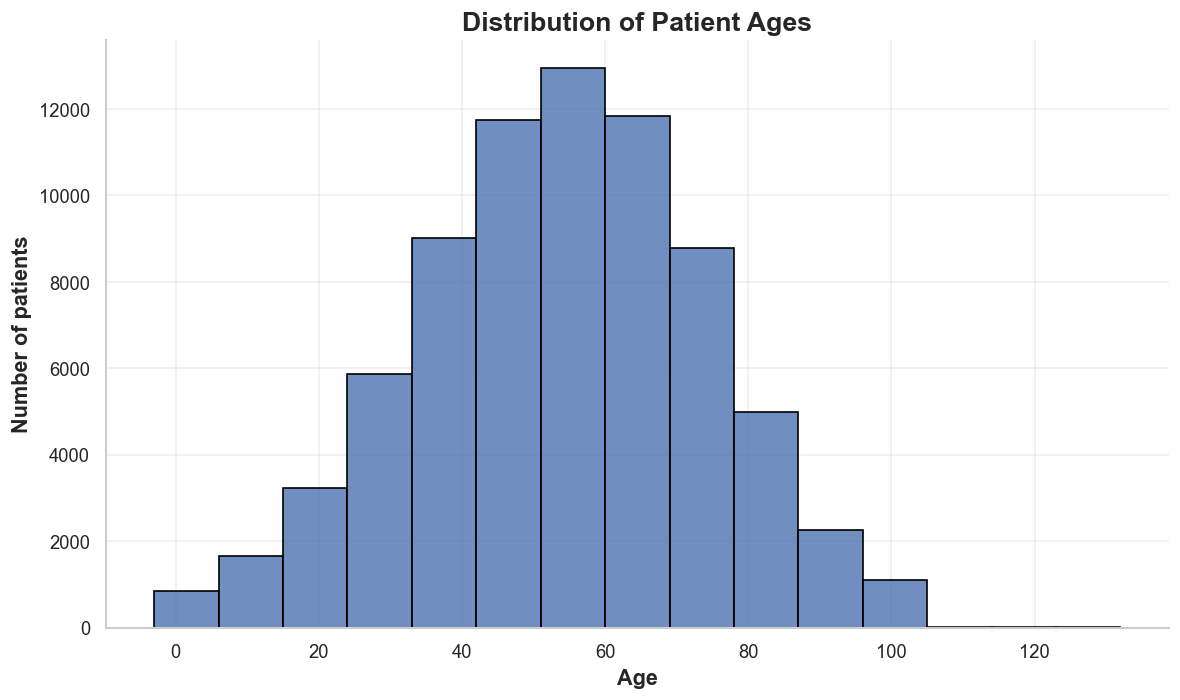

In [43]:
plt.figure(figsize=(10,6))
sns.histplot(
    data=df,
    x="age",
    bins=15,
    edgecolor="black",
    alpha=0.8
)
plt.title("Distribution of Patient Ages")
plt.xlabel("Age")
plt.ylabel("Number of patients")
plt.tight_layout()

# Chose histplot because is the standard visual for distributions.

### Interpretation

- The age distribution appears approximately bell-shaped.
- Most patients are concentrated around the middle-age ranges.
- No strong multimodal pattern is immediately visible.


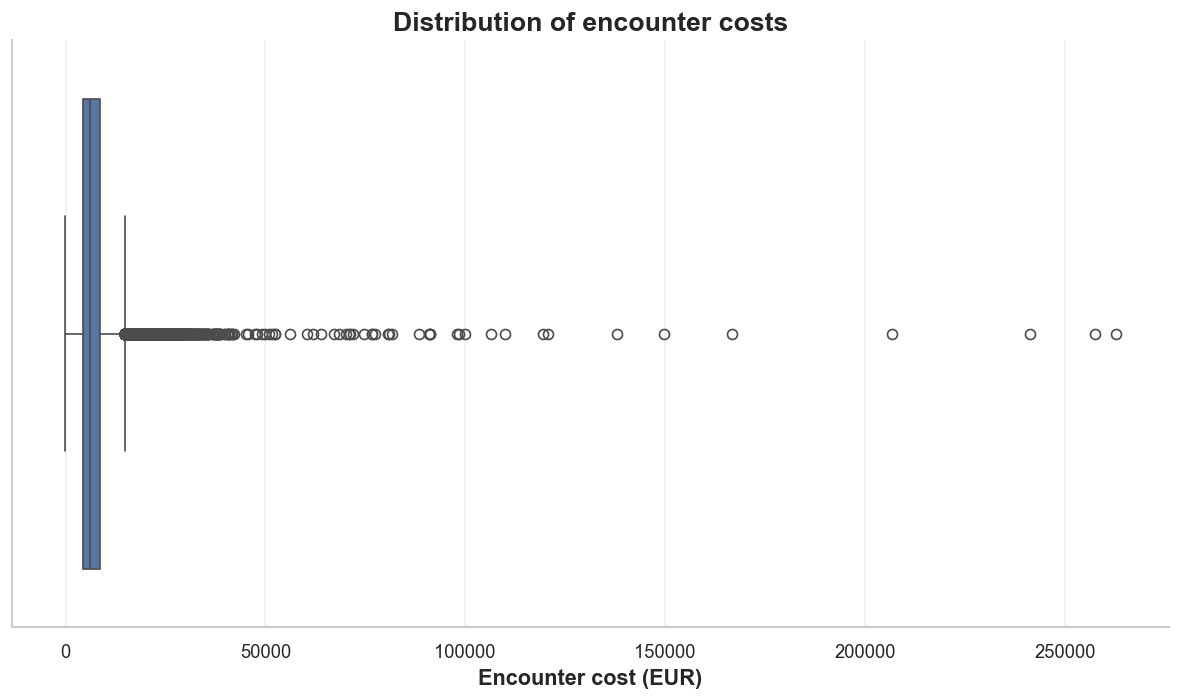

In [45]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x="total_cost_eur"
)
plt.title("Distribution of encounter costs")
plt.xlabel("Encounter cost (EUR)")
plt.tight_layout()

# I've chosen the boxplot over the histogram because, although it is a continuous variable, it is easier to visualize outliers, median and quartiles

### Interpretation

- Most encounter costs fall within a relatively compact central range.
- The distribution contains several substantial high-cost outliers.
- These extreme values may materially influence the mean and total spending.


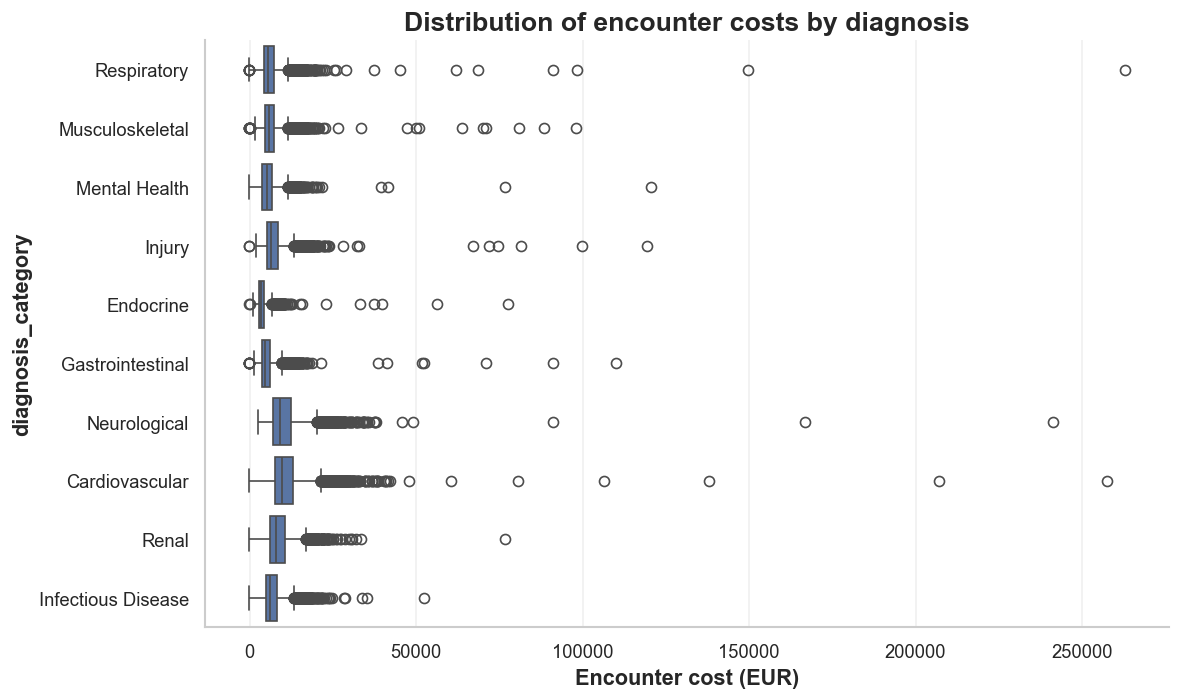

In [91]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x="total_cost_eur",
    y="diagnosis_category"
)
plt.title("Distribution of encounter costs by diagnosis")
plt.xlabel("Encounter cost (EUR)")
plt.tight_layout()

# I've chosen the boxplot over the histogram because, although it is a continuous variable, it is easier to visualize outliers, median and quartiles

## 9. Key Findings

This section will be finalized once the remaining analytical and visualization exercises are complete.

### Current observations

- The dataset has been reviewed for structure, missingness, and duplicate records.
- Encounter costs show a concentrated central distribution with notable high-cost outliers.
- Patient ages appear broadly centered around middle age without an obvious multimodal pattern.
- Patient-level, diagnosis-level, readmission, and time-based analyses have been developed.

### Next steps

- Continue the remaining visualization exercises.
- Add concise interpretations beneath each major table and chart.
- Consolidate the strongest findings into an executive summary.
- Document limitations and potential follow-up analyses.
